# Queda Livre: Modelagem Matemática e Implementação Computacional

Este notebook segue o roteiro proposto para o trabalho prático de modelagem matemática da Queda Livre, unindo teoria, programação e análise de resultados. Cada etapa é explicada em detalhes, com células Markdown e código Python, além de salvar os dados e gráficos gerados.

In [119]:
from pathlib import Path
import os
import shutil
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Diretório base do projeto (pasta do notebook)
base_dir = Path().resolve()

# Diretórios principais de dados
input_dir = base_dir / 'dados' / 'input'

output_dir = base_dir / 'dados' / 'output'

output_queda_livre_particula_dir = output_dir / 'queda_livre_particula'
output_queda_livre_corpo_rigido_dir = output_dir / 'queda_livre_corpo_rigido'
output_corpo_rigido_linear_simplificado_dir = output_queda_livre_corpo_rigido_dir / 'linear_simplificado'
output_corpo_rigido_linear_completo_dir = output_queda_livre_corpo_rigido_dir / 'linear_completo'
output_corpo_rigido_quadratica_simplificado_dir = output_queda_livre_corpo_rigido_dir / 'quadratica_simplificado'
output_corpo_rigido_quadratica_completo_dir = output_queda_livre_corpo_rigido_dir / 'quadratica_completo'
output_resistencia_ar_dir = output_dir / 'queda_livre_resistencia_ar'
output_acuracia_dir = output_dir / 'acuracia'

# Diretórios principais de gráficos
graficos_dir = base_dir / 'graficos'
graficos_queda_livre_particula_dir = graficos_dir / 'queda_livre_particula'
graficos_queda_livre_corpo_rigido_dir = graficos_dir / 'queda_livre_corpo_rigido'
graficos_queda_livre_corpo_rigido_linear_simplificado_dir = graficos_queda_livre_corpo_rigido_dir / 'linear_simplificado'
graficos_queda_livre_corpo_rigido_linear_completo_dir = graficos_queda_livre_corpo_rigido_dir / 'linear_completo'
graficos_queda_livre_corpo_rigido_quadratica_simplificado_dir = graficos_queda_livre_corpo_rigido_dir / 'quadratica_simplificado'
graficos_queda_livre_corpo_rigido_quadratica_completo_dir = graficos_queda_livre_corpo_rigido_dir / 'quadratica_completo'

graficos_comparativo_dir = graficos_dir / 'comparativo'
graficos_resistencia_ar_dir = graficos_dir / 'queda_livre_resistencia_ar'
graficos_acuracia_dir = graficos_dir / 'acuracia'

# Lista de todas as pastas a serem criadas
pastas = [
    input_dir, output_dir, output_queda_livre_particula_dir, output_queda_livre_corpo_rigido_dir,
    output_corpo_rigido_linear_simplificado_dir, output_corpo_rigido_linear_completo_dir,
    output_corpo_rigido_quadratica_simplificado_dir, output_corpo_rigido_quadratica_completo_dir,
    output_resistencia_ar_dir, output_acuracia_dir,

    graficos_dir, graficos_queda_livre_particula_dir, graficos_queda_livre_corpo_rigido_dir, graficos_queda_livre_corpo_rigido_linear_simplificado_dir,
    graficos_queda_livre_corpo_rigido_linear_completo_dir, graficos_queda_livre_corpo_rigido_quadratica_simplificado_dir, graficos_queda_livre_corpo_rigido_quadratica_completo_dir,
    graficos_comparativo_dir, graficos_resistencia_ar_dir, graficos_acuracia_dir
]

# Função para remover pasta (caso queira limpar tudo antes)
def remover_pasta(pasta):
    if pasta.exists() and pasta.is_dir():
        shutil.rmtree(pasta)
        print(f'Pasta removida: {pasta}')

# Limpeza opcional (descomente se quiser limpar antes de criar)
# for pasta in pastas:
#     remover_pasta(pasta)

# Cria todas as pastas (se não existirem)
for pasta in pastas:
    pasta.mkdir(exist_ok=True, parents=True)

print('Pastas criadas ou já existentes:')
for pasta in pastas:
    print(pasta)

# Função para salvar DataFrame de saída normalmente
def salvar_dados(df, pasta_destino, nome_arquivo):
    saida_csv = pasta_destino / nome_arquivo
    df.to_csv(saida_csv, index=False, float_format='%.4f')
    print(f'Resultado salvo em: {saida_csv}')

Pastas criadas ou já existentes:
D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\input
D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output
D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_particula
D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido
D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\linear_simplificado
D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\linear_completo
D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\quadratica_simplificado
D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\quadratica_completo
D:\GitHub\DoutoradoCefet\Prin

In [120]:
# Função para salvar DataFrame de saída normalmente
def salvar_dados(df, pasta_destino, nome_arquivo):
    saida_csv = os.path.join(pasta_destino, nome_arquivo) if isinstance(pasta_destino, str) else pasta_destino / nome_arquivo
    df.to_csv(saida_csv, index=False, float_format='%.4f')
    print(f'Resultado salvo em: {saida_csv}')

## 1. Criação das Funções

### 1.1 Função para simular a queda livre usando o método de Euler

In [121]:
# Função para simular a queda livre usando o método de Euler
# Agora retorna DataFrame padronizado

def simula_queda_livre_particula(H, V, g, dt):
    t = [0.0]
    x = [H]
    v = [V]
    a = [-g]
    while x[-1] > 0:
        t.append(t[-1] + dt)
        x.append(x[-1] + v[-1]*dt)
        v.append(v[-1] - g*dt)
        a.append(-g)
    if x[-1] < 0:
        x[-1] = 0
    df = pd.DataFrame({'tempo': t, 'posicao': x, 'velocidade': v, 'aceleracao': a})
    return df

### 1.2. Função para Modelagem de corpo rígido em queda livre com resistência 

#### 1.2.2 Função com resistência linear

In [122]:
def simula_queda_livre_corpo_rigido_linear_simplificada(H, V, g, dt, k):
    """
    Simula a queda livre com resistência do ar linear (F = -k*v).
    Parâmetros:
        H: altura inicial (m)
        V: velocidade inicial (m/s)
        g: gravidade (m/s²)
        dt: passo de tempo (s)
        k: coeficiente de resistência linear (1/s)
    Retorna:
        DataFrame com tempo, posição, velocidade e aceleração
    """
    t = [0.0]
    x = [H]
    v = [V]
    a = [-g - k * V]

    while x[-1] > 0:
        a_atual = -g - k * v[-1]
        v.append(v[-1] + a_atual * dt)
        x.append(x[-1] + v[-2] * dt)
        t.append(t[-1] + dt)
        a.append(a_atual)
        if x[-1] < 0:
            x[-1] = 0  # Corrige para parar exatamente no solo

    df = pd.DataFrame({'tempo': t, 'posicao': x, 'velocidade': v, 'aceleracao': a})
    return df

In [123]:
def simula_queda_livre_corpo_rigido_linear_completo(H, V, g, dt, m, eta, r):
    """
    Simula queda livre com resistência linear completa (Lei de Stokes).
    Modelo: Fd = 6 * pi * eta * r * v
    Válido para objetos pequenos em regime laminar.
    """
    import numpy as np
    import pandas as pd

    t = [0.0]
    x = [H]
    v = [V]
    # Calcula a aceleração inicial
    Fd0 = 6 * np.pi * eta * r * V
    a = [-g - Fd0 / m]

    while x[-1] > 0:
        # força de arrasto linear realista
        Fd = 6 * np.pi * eta * r * v[-1]
        # aceleração
        a_atual = -g - Fd / m
        a.append(a_atual)
        # velocidade
        v.append(v[-1] + a_atual * dt)
        # posição
        x.append(x[-1] + v[-2] * dt)
        # tempo
        t.append(t[-1] + dt)
        if x[-1] <= 0:
            x[-1] = 0
            break

    # garantir tamanho igual
    if len(a) < len(t):
        a.append(a[-1])

    return pd.DataFrame({
        'tempo': t,
        'posicao': x,
        'velocidade': v,
        'aceleracao': a
    })

#### 1.2.2 Função com resistência quadrática

In [124]:
def simula_queda_livre_corpo_rigido_quadratica_simplificada(H, V, g, dt, c):
    """
    Simula queda livre com resistência do ar quadrática simplificada.
    Modelo: Fd = -c * v * |v|
    Retorna DataFrame padronizado.
    """

    t = [0.0]
    x = [H]
    v = [V]
    a = [-g - c * v[-1] * abs(v[-1])]

    while x[-1] > 0:

        # tempo
        t.append(t[-1] + dt)

        # aceleração quadrática (arrasto sempre contrário ao movimento)
        a_atual = -g - c * v[-1] * abs(v[-1])
        a.append(a_atual)

        # velocidade
        v.append(v[-1] + a_atual * dt)

        # posição (queda → diminui x)
        x.append(x[-1] + v[-2] * dt)

        # parar exatamente no chão
        if x[-1] <= 0:
            x[-1] = 0
            break

    df = pd.DataFrame({
        'tempo': t,
        'posicao': x,
        'velocidade': v,
        'aceleracao': a
    })

    return df

In [125]:
def simula_queda_livre_corpo_rigido_quadratica_completo(H, V, m, Cd, A, rho, g, dt):
    """
    Simula a queda livre de um corpo rígido com resistência quadrática completa.
    Modelo realista: Fd = 0.5 * rho * Cd * A * v^2
    """
    import pandas as pd

    t = [0.0]
    x = [H]
    v = [V]
    # Força de arrasto inicial
    Fr0 = 0.5 * Cd * rho * A * V**2
    a = [-g - Fr0 / m]

    while x[-1] > 0:
        # força de arrasto (sempre contrária ao movimento)
        Fr = 0.5 * Cd * rho * A * v[-1]**2
        # aceleração
        a_atual = -g - Fr / m
        a.append(a_atual)
        # velocidade
        v.append(v[-1] + a_atual * dt)
        # posição (queda → diminui x)
        x.append(x[-1] + v[-1] * dt)
        # tempo
        t.append(t[-1] + dt)
        # parar exatamente no chão
        if x[-1] <= 0:
            x[-1] = 0
            break

    # garantir que aceleração tenha o mesmo tamanho
    if len(a) < len(t):
        a.append(a[-1])

    df = pd.DataFrame({
        'tempo': t,
        'posicao': x,
        'velocidade': v,
        'aceleracao': a
    })

    return df

### 1.4. Função para Apresentação dos Gráficos: Posição, Velocidade, Aceleração em função do Tempo e acurácia

In [126]:
def plotar_grafico_posicao_tempo(resultados, dt_list, graficos_dir, titulo, nome_arquivo):
    plt.figure(figsize=(8,5))
    for dt in dt_list:
        t = resultados[dt]['t']
        x = resultados[dt]['x']
        plt.plot(t, x, label=f'dt = {dt} s')  # unidade explícita
    plt.xlabel('Tempo (s)')
    plt.ylabel('Posição (m)')
    plt.title(f'Posição x Tempo ({titulo})')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(graficos_dir, nome_arquivo))
    plt.show()

def plotar_grafico_velocidade_tempo(resultados, dt_list, graficos_dir, titulo, nome_arquivo):
    plt.figure(figsize=(8,5))
    for dt in dt_list:
        t = resultados[dt]['t']
        v = resultados[dt]['v']
        v_abs = [abs(vi) for vi in v]
        plt.plot(t, v_abs, label=f'dt = {dt} s')  # unidade explícita
    plt.xlabel('Tempo (s)')
    plt.ylabel('Velocidade (m/s)')
    plt.title(f'Velocidade x Tempo ({titulo})')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(graficos_dir, nome_arquivo))
    plt.show()

def plotar_grafico_aceleracao_tempo(resultados, dt_list, graficos_dir, titulo, nome_arquivo):
    plt.figure(figsize=(8,5))
    for dt in dt_list:
        t = resultados[dt]['t']
        g = -9.81
        aceleracao = [g for _ in t]
        plt.plot(t, aceleracao, label=f'dt = {dt} s')  # unidade explícita
    plt.xlabel('Tempo (s)')
    plt.ylabel('Aceleração (m/s²)')
    plt.title(f'Aceleração x Tempo ({titulo})')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(graficos_dir, nome_arquivo))
    plt.show()


In [127]:

def plotar_comparativo_modelos_posicao(dt, modelos_arquivos, graficos_dir, titulo, nome_arquivo):
    plt.figure(figsize=(10, 6))
    for modelo, arquivo in modelos_arquivos.items():
        df = pd.read_csv(arquivo)
        plt.plot(df['tempo'], df['posicao'], label=modelo)
    plt.xlabel('Tempo (s)')
    plt.ylabel('Posição (m)')
    plt.title(f'Comparativo de Posição - dt = {dt} ({titulo})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(graficos_dir, nome_arquivo))
    plt.show()

def plotar_comparativo_modelos_velocidade(dt, modelos_arquivos, graficos_dir, titulo, nome_arquivo):
    plt.figure(figsize=(10, 6))
    for modelo, arquivo in modelos_arquivos.items():
        df = pd.read_csv(arquivo)
        plt.plot(df['tempo'], df['velocidade'], label=modelo)
    plt.xlabel('Tempo (s)')
    plt.ylabel('Velocidade (m/s)')
    plt.title(f'Comparativo de Velocidade - dt = {dt} ({titulo})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(graficos_dir, nome_arquivo))
    plt.show()

def plotar_comparativo_modelos_aceleracao(dt, modelos_arquivos, graficos_dir, titulo, nome_arquivo):
    plt.figure(figsize=(10, 6))
    for modelo, arquivo in modelos_arquivos.items():
        df = pd.read_csv(arquivo)
        if 'aceleracao' in df.columns:
            aceleracao = df['aceleracao']
        else:
            aceleracao = [-9.81 for _ in df['tempo']]
        plt.plot(df['tempo'], aceleracao, label=modelo)
    plt.xlabel('Tempo (s)')
    plt.ylabel('Aceleração (m/s²)')
    plt.title(f'Comparativo de Aceleração - dt = {dt} ({titulo})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(graficos_dir, nome_arquivo))
    plt.show()

In [128]:

def plotar_acuracia_dt(caminho_csv, titulo, nome_arquivo, graficos_dir):
    df = pd.read_csv(caminho_csv)
    dt_list = df['dt (s)']  # Atualizado para o nome com unidade
    erros = df['erro_relativo']
    plt.figure(figsize=(8,5))
    plt.plot(dt_list, erros, marker='o', linestyle='-', color='tab:blue')
    plt.xlabel('Passo de tempo (dt) [s]')
    plt.ylabel('Erro relativo (v_final numérico vs. analítico)')
    plt.title(titulo)
    plt.grid(True)
    plt.tight_layout()
    caminho = graficos_dir / nome_arquivo
    plt.savefig(caminho)
    plt.show()
    print(f'Gráfico salvo em: {caminho}')

### 1.5. Função Esutdo da acurácia Acurácia em Função do Tamanhao do Passo

In [129]:
# -----------------------------
# ANALÍTICOS
# -----------------------------

def vfinal_analitico_particula(V, g, t):
    return V - g * t

def vfinal_analitico_corpo_rigido_linear_simplificado(V, g, c, t):
    return -g/c + (V + g/c) * np.exp(-c * t)


# -----------------------------
# SIMULAÇÕES
# -----------------------------

def simula_queda_livre_particula(H, V, g, dt):
    """
    Queda livre sem resistência do ar.
    """
    t = [0.0]
    x = [H]
    v = [V]
    a = [-g]

    while x[-1] > 0:
        t.append(t[-1] + dt)
        a.append(-g)
        v.append(v[-1] - g * dt)
        x.append(x[-1] + v[-2] * dt)

        if x[-1] <= 0:
            x[-1] = 0
            break

    return pd.DataFrame({
        'tempo': t,
        'posicao': x,
        'velocidade': v,
        'aceleracao': a
    })


def simula_queda_livre_corpo_rigido_linear_simplificado(H, V, g, dt, c):
    """
    Queda livre com resistência linear simplificada: Fd = -c v
    """
    t = [0.0]
    x = [H]
    v = [V]
    a = [-g - c * v[-1]]

    while x[-1] > 0:
        t.append(t[-1] + dt)

        a_atual = -g - c * v[-1]
        a.append(a_atual)

        v.append(v[-1] + a_atual * dt)

        x.append(x[-1] + v[-2] * dt)

        if x[-1] <= 0:
            x[-1] = 0
            break

    return pd.DataFrame({
        'tempo': t,
        'posicao': x,
        'velocidade': v,
        'aceleracao': a
    })


# -----------------------------
# ERRO RELATIVO
# -----------------------------

def erro_relativo(v_num, v_ana):
    return abs((v_num - v_ana) / v_ana) if v_ana != 0 else np.nan


# -----------------------------
# FUNÇÃO DE ACURÁCIA
# -----------------------------

def acuracia_vfinal(simulador, v_analitico_func, H, V, g, dt_list, extra_params=None):
    v_finais = []
    t_finais = []
    v_analiticos = []
    erros = []

    for dt in dt_list:

        if extra_params is not None:
            df = simulador(H, V, g, dt, *extra_params)
        else:
            df = simulador(H, V, g, dt)

        t_final = df['tempo'].iloc[-1]
        v_final = df['velocidade'].iloc[-1]

        if extra_params is not None:
            v_ana = v_analitico_func(V, g, *extra_params, t_final)
        else:
            v_ana = v_analitico_func(V, g, t_final)

        v_finais.append(v_final)
        t_finais.append(t_final)
        v_analiticos.append(v_ana)
        erros.append(erro_relativo(v_final, v_ana))

    return v_finais, t_finais, v_analiticos, erros


# -----------------------------
# FUNÇÃO PRINCIPAL DE ACURÁCIA
# -----------------------------

def simula_acuracia_parametrizada(H, V, g, dt_inicial, dt_final, dt_step, output_acuracia_dir, k):
    dt_list = np.arange(dt_inicial, dt_final + dt_step, dt_step).tolist()

    # --- SEM resistência ---
    v_finais, t_finais, v_analiticos, erros = acuracia_vfinal(
        simula_queda_livre_particula,
        vfinal_analitico_particula,
        H, V, g, dt_list
    )

    df_sem = pd.DataFrame({
        'dt (s)': dt_list,
        'tempo_final (s)': t_finais,
        'v_final_num (m/s)': v_finais,
        'v_final_analitico (m/s)': v_analiticos,
        'erro_relativo': erros
    })

    salvar_dados(df_sem, output_acuracia_dir, 'acuracia_sem_resistencia.csv')

    # --- COM resistência linear ---
    v_finais, t_finais, v_analiticos, erros = acuracia_vfinal(
        simula_queda_livre_corpo_rigido_linear_simplificado,
        vfinal_analitico_corpo_rigido_linear_simplificado,
        H, V, g, dt_list,
        extra_params=[k]
    )

    df_lin = pd.DataFrame({
        'dt (s)': dt_list,
        'tempo_final (s)': t_finais,
        'v_final_num (m/s)': v_finais,
        'v_final_analitico (m/s)': v_analiticos,
        'erro_relativo': erros
    })

    salvar_dados(df_lin, output_acuracia_dir, 'acuracia_com_resistencia_linear.csv')




## 2. Implementação dos Modelos
### 2.1. Parâmetros

## Tabela Comparativa dos Modelos de Arrasto

| Modelo                   | Coeficiente                      | Fórmula da Força de Arrasto                        | Tipo         |
|--------------------------|----------------------------------|----------------------------------------------------|--------------|
| Linear simplificado      | $k$                              | $F_d = -k v$                                       | Aproximação  |
| Linear completo (Stokes) | $k = 6\pi \eta r$                | $F_d = -6\pi \eta r v$                             | Físico       |
| Quadrático simplificado  | $c$                              | $F_d = -c v |v|$                                   | Aproximação  |
| Quadrático completo      | $c = \\frac{1}{2}\\rho C_d A$    | $F_d = -\\frac{1}{2}\\rho C_d A v |v|$             | Físico       |

In [130]:
# ============================================================
#  PARÂMETROS BÁSICOS DO MOVIMENTO
# ============================================================

H = 600.0        # altura inicial (m)
V = 0.0          # velocidade inicial (m/s)
g = 9.81         # gravidade (m/s²)

# ============================================================
#  PASSOS DE TEMPO PARA SIMULAÇÃO
# ============================================================

dt_inicial = 0.0001   # menor passo para estudo de acurácia
dt_final   = 10     # maior passo para estudo de acurácia
dt_step    = 0.0001   # incremento entre passos

dt_list = [dt_inicial, 0.1, 0.1, 0.01, dt_final]  # passos fixos para comparação


# ============================================================
#  MODELO DE RESISTÊNCIA LINEAR
# ============================================================

k = 2.0  # coeficiente de resistência linear (1/s)

# Resistência linear completa (Lei de Stokes)
eta = 1.8e-5   # viscosidade dinâmica do ar (Pa·s)
r   = 0.01     # raio da esfera (m)

# ============================================================
#  MODELO DE RESISTÊNCIA QUADRÁTICA
# ============================================================

# Quadrática simplificada
c = 2.0  # coeficiente quadrático simplificado (1/m)

# Quadrática completa (arrasto aerodinâmico)
m   = 1.0     # massa do corpo (kg)
Cd  = 0.47    # coeficiente de arrasto (esfera)
A   = 0.01    # área frontal (m²)
rho = 1.225   # densidade do ar (kg/m³)

In [131]:
# ============================================================
# Entrada para simula_queda_livre (sem resistência)
# ============================================================

df_entrada_queda_livre = pd.DataFrame([
    {
        'H (m)': H,
        'V (m/s)': V,
        'g (m/s²)': g,
        'dt (s)': dt
    }
    for dt in dt_list
])

salvar_dados(df_entrada_queda_livre, input_dir, 'entrada_queda_livre.csv')


# ============================================================
# Entrada para simula_queda_livre_linear (resistência linear simplificada)
# ============================================================

df_entrada_linear_simplificada = pd.DataFrame([
    {
        'H (m)': H,
        'V (m/s)': V,
        'g (m/s²)': g,
        'dt (s)': dt,
        'k (1/s)': k
    }
    for dt in dt_list
])

salvar_dados(df_entrada_linear_simplificada, input_dir, 'entrada_queda_livre_linear_simplificada.csv')


# ============================================================
# Entrada para simula_queda_livre_linear_completo (Lei de Stokes)
# ============================================================

df_entrada_linear_completo = pd.DataFrame([
    {
        'H (m)': H,
        'V (m/s)': V,
        'g (m/s²)': g,
        'dt (s)': dt,
        'm (kg)': m,
        'eta (Pa·s)': eta,
        'r (m)': r
    }
    for dt in dt_list
])

salvar_dados(df_entrada_linear_completo, input_dir, 'entrada_queda_livre_linear_completo.csv')


# ============================================================
# Entrada para simula_queda_livre_quadratica_simplificada
# ============================================================

df_entrada_quadratica_simplificada = pd.DataFrame([
    {
        'H (m)': H,
        'V (m/s)': V,
        'g (m/s²)': g,
        'dt (s)': dt,
        'c (1/m)': c
    }
    for dt in dt_list
])

salvar_dados(df_entrada_quadratica_simplificada, input_dir, 'entrada_queda_livre_quadratica_simplificada.csv')


# ============================================================
# Entrada para simula_queda_livre_quadratica_completo
# ============================================================

df_entrada_quadratica_completo = pd.DataFrame([
    {
        'H (m)': H,
        'V (m/s)': V,
        'm (kg)': m,
        'Cd (-)': Cd,
        'A (m²)': A,
        'rho (kg/m³)': rho,
        'g (m/s²)': g,
        'dt (s)': dt
    }
    for dt in dt_list
])

salvar_dados(df_entrada_quadratica_completo, input_dir, 'entrada_queda_livre_quadratica_completo.csv')


# ============================================================
# Entrada para simula_queda_livre_resistencia (geral)
# ============================================================

df_simula_queda_livre_resistencia = pd.DataFrame([
    {
        'H (m)': H,
        'V (m/s)': V,
        'g (m/s²)': g,
        'dt (s)': dt,
        'm (kg)': m,
        'Cd (-)': Cd,
        'A (m²)': A,
        'rho (kg/m³)': rho
    }
    for dt in dt_list
])

salvar_dados(df_simula_queda_livre_resistencia, input_dir, 'entrada_queda_livre_resistencia_ar.csv')

# ============================================================
# Entrada para estudo de acurácia
# ============================================================

df_entrada_acuracia = pd.DataFrame([
    {
        'H (m)': H,
        'V (m/s)': V,
        'g (m/s²)': g,
        'dt_inicial (s)': dt_inicial,
        'dt_final (s)': dt_final,
        'dt_step (s)': dt_step,

        # Resistência linear simplificada
        'k (1/s)': k
    }
], index=[0])

salvar_dados(df_entrada_acuracia, input_dir, 'entrada_acuracia.csv')

Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\input\entrada_queda_livre.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\input\entrada_queda_livre_linear_simplificada.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\input\entrada_queda_livre_linear_completo.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\input\entrada_queda_livre_quadratica_simplificada.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\input\entrada_queda_livre_quadratica_completo.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\input\entrada_queda_livre_resistencia_ar.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\input\entra

In [132]:
# ============================================================
# Construção da tabela de parâmetros (formato padrão)
# ============================================================

def construir_tabela_parametros(parametros):
    return pd.DataFrame([
        {
            "Parâmetro": p,
            "Descrição": desc,
            "Valor": val,
            "Unidade": unidade
        }
        for p, (desc, val, unidade) in parametros.items()
    ])


# ============================================================
# Tabela – Queda Livre (sem resistência)
# ============================================================

param_queda_livre = {
    "H":  ("Altura Inicial",            H,   "m"),
    "V":  ("Velocidade Inicial",        V,   "m/s"),
    "g":  ("Aceleração da Gravidade",   g,   "m/s²"),
}

df_param_queda_livre = construir_tabela_parametros(param_queda_livre)
salvar_dados(df_param_queda_livre, input_dir, "parametros_queda_livre.csv")


# ============================================================
# Tabela – Resistência Linear Simplificada
# ============================================================

param_linear_simplificada = {
    "H":  ("Altura Inicial",            H,   "m"),
    "V":  ("Velocidade Inicial",        V,   "m/s"),
    "g":  ("Aceleração da Gravidade",   g,   "m/s²"),
    "k":  ("Coeficiente Linear",        k,   "1/s"),
}

df_param_linear_simplificada = construir_tabela_parametros(param_linear_simplificada)
salvar_dados(df_param_linear_simplificada, input_dir, "parametros_linear_simplificada.csv")


# ============================================================
# Tabela – Resistência Linear Completa (Lei de Stokes)
# ============================================================

param_linear_completo = {
    "H":   ("Altura Inicial",            H,    "m"),
    "V":   ("Velocidade Inicial",        V,    "m/s"),
    "g":   ("Aceleração da Gravidade",   g,    "m/s²"),
    "m":   ("Massa",                     m,    "kg"),
    "eta": ("Viscosidade do Ar",         eta,  "Pa·s"),
    "r":   ("Raio da Esfera",            r,    "m"),
}

df_param_linear_completo = construir_tabela_parametros(param_linear_completo)
salvar_dados(df_param_linear_completo, input_dir, "parametros_linear_completo.csv")


# ============================================================
# Tabela – Resistência Quadrática Simplificada
# ============================================================

param_quadratica_simplificada = {
    "H":  ("Altura Inicial",            H,   "m"),
    "V":  ("Velocidade Inicial",        V,   "m/s"),
    "g":  ("Aceleração da Gravidade",   g,   "m/s²"),
    "c":  ("Coeficiente Quadrático",    c,   "1/m"),
}

df_param_quadratica_simplificada = construir_tabela_parametros(param_quadratica_simplificada)
salvar_dados(df_param_quadratica_simplificada, input_dir, "parametros_quadratica_simplificada.csv")


# ============================================================
# Tabela – Resistência Quadrática Completa
# ============================================================

param_quadratica_completo = {
    "H":    ("Altura Inicial",            H,    "m"),
    "V":    ("Velocidade Inicial",        V,    "m/s"),
    "g":    ("Aceleração da Gravidade",   g,    "m/s²"),
    "m":    ("Massa",                     m,    "kg"),
    "Cd":   ("Coeficiente de Arrasto",    Cd,   "-"),
    "A":    ("Área Frontal",              A,    "m²"),
    "rho":  ("Densidade do Ar",           rho,  "kg/m³"),
}

df_param_quadratica_completo = construir_tabela_parametros(param_quadratica_completo)
salvar_dados(df_param_quadratica_completo, input_dir, "parametros_quadratica_completo.csv")


# ============================================================
# Tabela – Estudo de Acurácia
# ============================================================

param_acuracia = {
    "H":            ("Altura Inicial",            H,           "m"),
    "V":            ("Velocidade Inicial",        V,           "m/s"),
    "g":            ("Aceleração da Gravidade",   g,           "m/s²"),
    "dt_inicial":   ("Passo Inicial",             dt_inicial,  "s"),
    "dt_final":     ("Passo Final",               dt_final,    "s"),
    "dt_step":      ("Incremento do Passo",       dt_step,     "s"),
    "k":            ("Coeficiente Linear",        k,           "1/s"),
}

df_param_acuracia = construir_tabela_parametros(param_acuracia)
salvar_dados(df_param_acuracia, input_dir, "parametros_acuracia.csv")

Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\input\parametros_queda_livre.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\input\parametros_linear_simplificada.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\input\parametros_linear_completo.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\input\parametros_quadratica_simplificada.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\input\parametros_quadratica_completo.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\input\parametros_acuracia.csv


### 2.2. Implementação do Modelo de uma Partícula em Queda Livre

Neste passo, vamos implementar o modelo discreto da queda livre usando o método de Euler. O objetivo é calcular, passo a passo, a posição e a velocidade de uma pedra até ela atingir o solo.

Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_particula\saida_queda_livre_dt_0_0001.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_particula\saida_queda_livre_dt_0_1.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_particula\saida_queda_livre_dt_0_1.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_particula\saida_queda_livre_dt_0_01.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_particula\saida_queda_livre_dt_10.csv


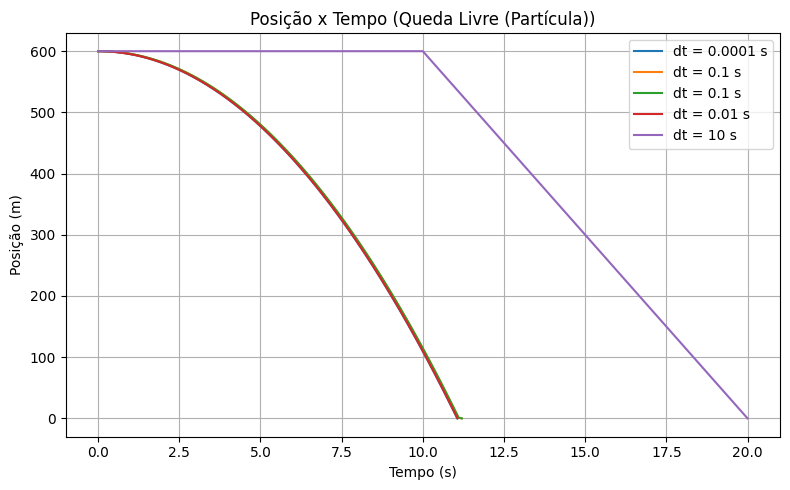

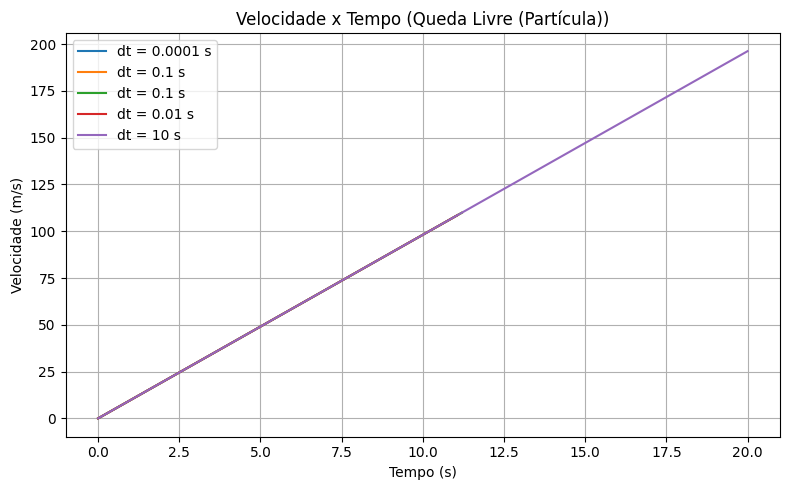

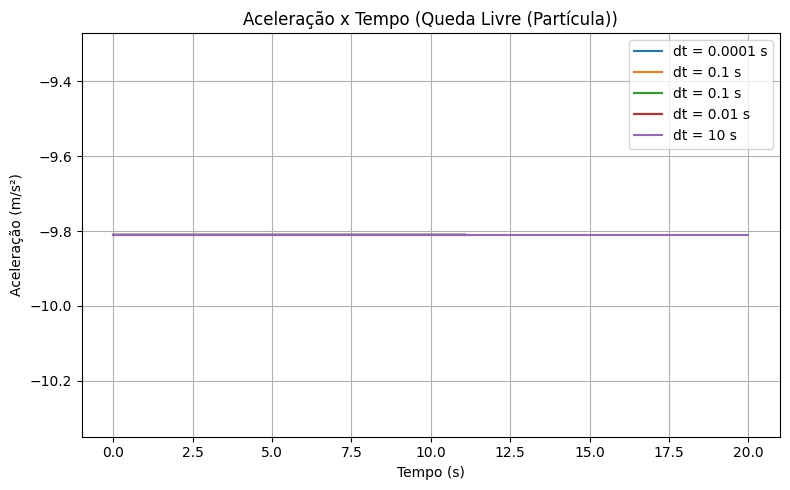

In [133]:
resultados_csv = {}

for dt in dt_list:
    # Executa a simulação
    df = simula_queda_livre_particula(H, V, g, dt)

    # CORREÇÃO: Aceleração constante com sinal negativo (a = -g)
    # Reflete o modelo físico apontado na sua fundamentação teórica.
    df["aceleracao"] = -g

    # Armazena os resultados
    resultados_csv[dt] = {
        't': df['tempo'].tolist(),
        'x': df['posicao'].tolist(),
        'v': df['velocidade'].tolist(),
        'a': df['aceleracao'].tolist()
    }

    # Nome do arquivo
    nome_arquivo = f"saida_queda_livre_dt_{str(dt).replace('.', '_')}.csv"

    # Salva o CSV
    salvar_dados(df, output_queda_livre_particula_dir, nome_arquivo)


# ============================================================
# Gráficos
# ============================================================

plotar_grafico_posicao_tempo(
    resultados_csv,
    dt_list,
    graficos_queda_livre_particula_dir,
    "Queda Livre (Partícula)",
    "grafico_posicao_tempo_multidt.png"
)

plotar_grafico_velocidade_tempo(
    resultados_csv,
    dt_list,
    graficos_queda_livre_particula_dir,
    "Queda Livre (Partícula)",
    "grafico_velocidade_tempo_multidt.png"
)

plotar_grafico_aceleracao_tempo(
    resultados_csv,
    dt_list,
    graficos_queda_livre_particula_dir,
    "Queda Livre (Partícula)",
    "grafico_aceleracao_tempo_multidt.png"
)


### 2.3. Implementação do Modelo Corpo Rígido em Queda Livre


#### 2.3.1. Simulação com Resistência Linear Simplificada

Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\linear_simplificado\saida_queda_livre_linear_dt_0_0001_k_2_0.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\linear_simplificado\saida_queda_livre_linear_dt_0_1_k_2_0.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\linear_simplificado\saida_queda_livre_linear_dt_0_1_k_2_0.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\linear_simplificado\saida_queda_livre_linear_dt_0_01_k_2_0.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\linear_simplificado\saida_queda_livre_linear_dt_10_k_2_0.csv


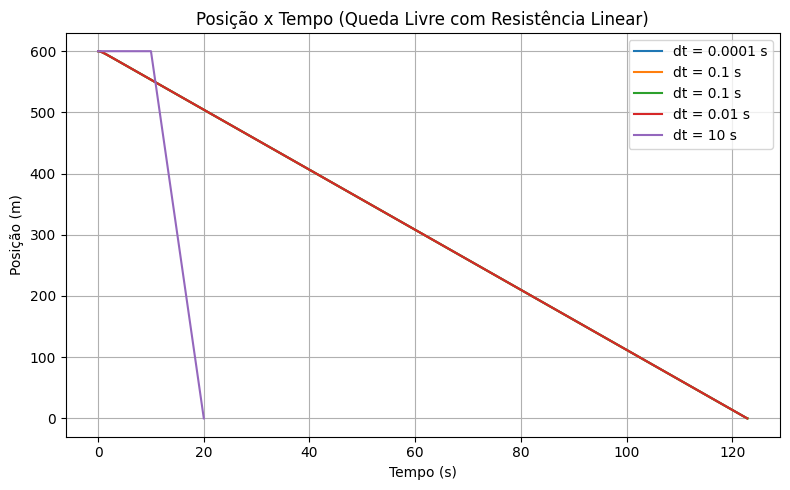

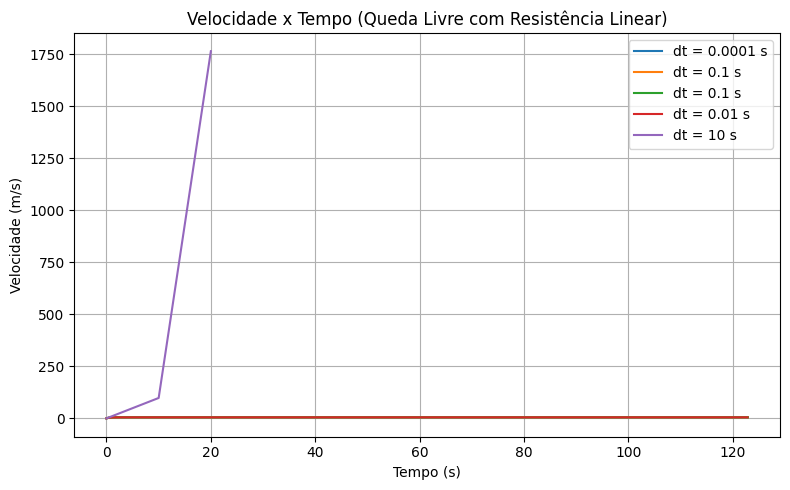

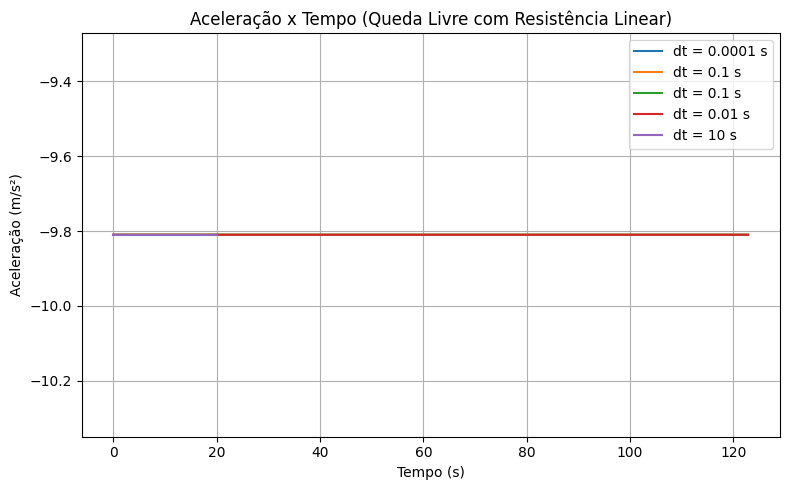

In [134]:
# Simulação, salvamento e preparação para plotagem (tudo junto)
resultados_csv_linear = {}

for dt in dt_list:
    df_linear = simula_queda_livre_corpo_rigido_linear_simplificada(H, V, g, dt, k)
    
    # Armazena resultados
    resultados_csv_linear[dt] = {
        't': df_linear['tempo'].tolist(),
        'x': df_linear['posicao'].tolist(),
        'v': df_linear['velocidade'].tolist(),
        'a': df_linear['aceleracao'].tolist()
    }

    # Nome do arquivo
    nome_arquivo = (
        f"saida_queda_livre_linear_dt_{str(dt).replace('.', '_')}"
        f"_k_{str(k).replace('.', '_')}.csv"
    )

    # Salva CSV
    salvar_dados(df_linear, output_corpo_rigido_linear_simplificado_dir, nome_arquivo)

# ============================================================
# Gráficos
# ============================================================


plotar_grafico_posicao_tempo(
    resultados_csv_linear,
    dt_list,
    graficos_queda_livre_corpo_rigido_linear_simplificado_dir,
    "Queda Livre com Resistência Linear",
    "grafico_posicao_tempo_linear.png"
)

plotar_grafico_velocidade_tempo(
    resultados_csv_linear,
    dt_list,
    graficos_queda_livre_corpo_rigido_linear_simplificado_dir,
    "Queda Livre com Resistência Linear",
    "grafico_velocidade_tempo_linear.png"
)

plotar_grafico_aceleracao_tempo(
    resultados_csv_linear,
    dt_list,
    graficos_queda_livre_corpo_rigido_linear_simplificado_dir,
    "Queda Livre com Resistência Linear",
    "grafico_aceleracao_tempo_linear.png"
)

#### 2.3.1. Simulação com Resistência Linear Completa

Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\linear_completo\saida_queda_livre_linear_completa_dt_0_0001.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\linear_completo\saida_queda_livre_linear_completa_dt_0_1.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\linear_completo\saida_queda_livre_linear_completa_dt_0_1.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\linear_completo\saida_queda_livre_linear_completa_dt_0_01.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\linear_completo\saida_queda_livre_linear_completa_dt_10.csv


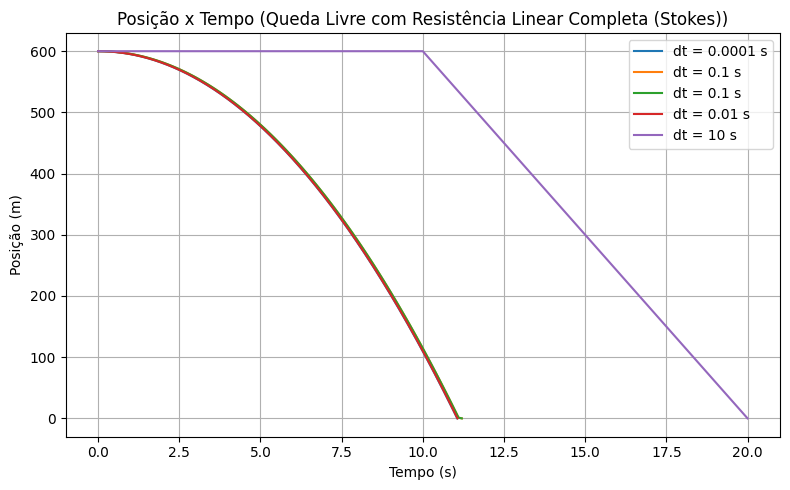

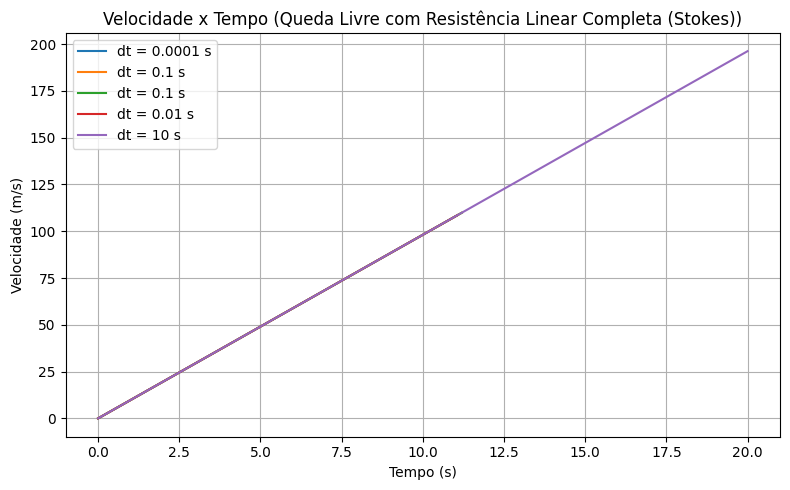

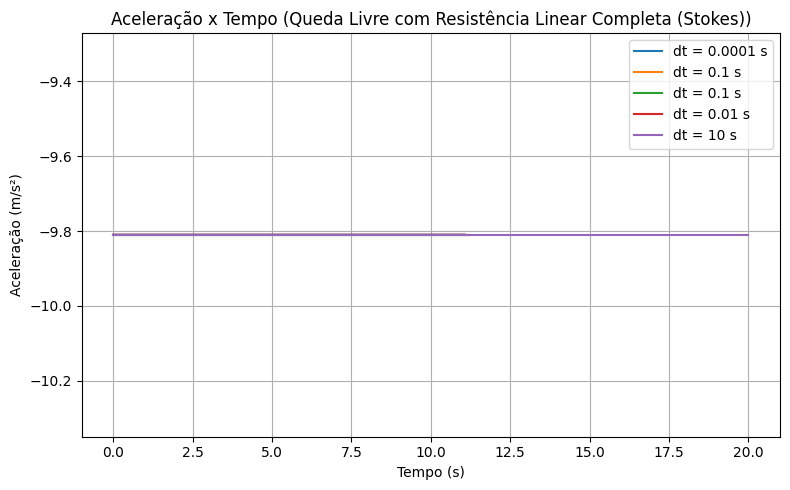

In [135]:
# ============================================================
# Simulação, salvamento e geração de gráficos
# Modelo: Corpo Rígido com Resistência Linear Completa (Stokes)
# ============================================================

resultados_csv_linear_completa = {}

for dt in dt_list:
    # Simula a queda livre com resistência linear completa (Stokes)
    df_linear_comp = simula_queda_livre_corpo_rigido_linear_completo(H, V, g, dt, m, eta, r)

    # Garante que a aceleração está correta (já calculada na função)
    # Se quiser recalcular: df_linear_comp["aceleracao"] = -g - (6 * np.pi * eta * r * df_linear_comp["velocidade"]) / m

    # Prepara os dados para os gráficos
    resultados_csv_linear_completa[dt] = {
        't': df_linear_comp['tempo'].tolist(),
        'x': df_linear_comp['posicao'].tolist(),
        'v': df_linear_comp['velocidade'].tolist(),
        'a': df_linear_comp['aceleracao'].tolist()
    }

    # Define o nome do arquivo de saída
    nome_arquivo = f'saida_queda_livre_linear_completa_dt_{str(dt).replace(".", "_")}.csv'
    salvar_dados(df_linear_comp, output_corpo_rigido_linear_completo_dir, nome_arquivo)

# ============================================================
# Geração dos gráficos para o modelo linear completo (Stokes)
# ============================================================

plotar_grafico_posicao_tempo(
    resultados_csv_linear_completa,
    dt_list,
    graficos_queda_livre_corpo_rigido_linear_completo_dir,
    'Queda Livre com Resistência Linear Completa (Stokes)',
    'grafico_posicao_tempo_linear_completa.png'
)

plotar_grafico_velocidade_tempo(
    resultados_csv_linear_completa,
    dt_list,
    graficos_queda_livre_corpo_rigido_linear_completo_dir,
    'Queda Livre com Resistência Linear Completa (Stokes)',
    'grafico_velocidade_tempo_linear_completa.png'
)

plotar_grafico_aceleracao_tempo(
    resultados_csv_linear_completa,
    dt_list,
    graficos_queda_livre_corpo_rigido_linear_completo_dir,
    'Queda Livre com Resistência Linear Completa (Stokes)',
    'grafico_aceleracao_tempo_linear_completa.png'
)

#### 2.3.1. Simulação com Resistência Quadrática Simplificada

Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\quadratica_simplificado\saida_queda_livre_quadratica_simplificado_dt_0_0001.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\quadratica_simplificado\saida_queda_livre_quadratica_simplificado_dt_0_1.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\quadratica_simplificado\saida_queda_livre_quadratica_simplificado_dt_0_1.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\quadratica_simplificado\saida_queda_livre_quadratica_simplificado_dt_0_01.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\quadratica_simplif

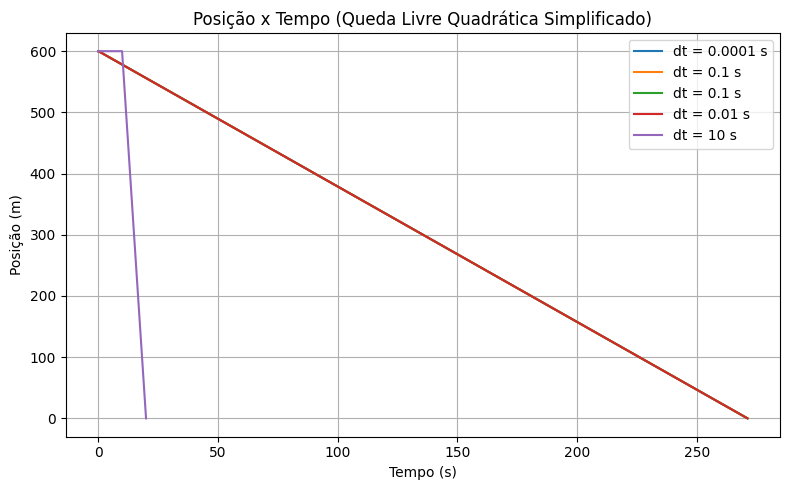

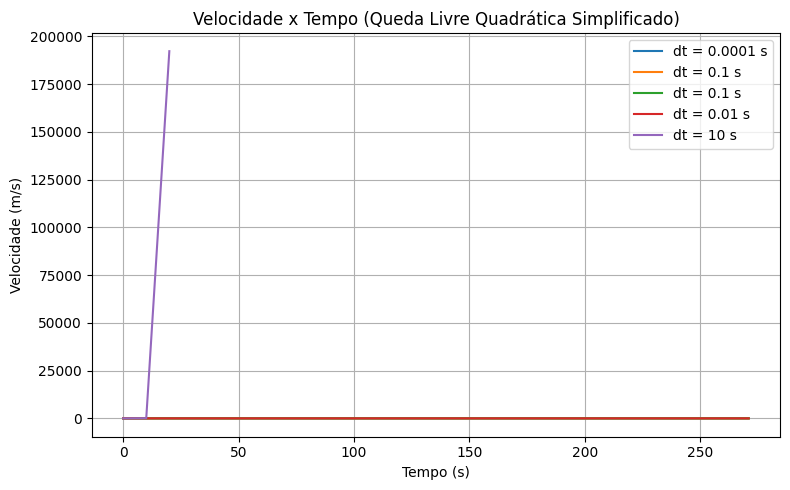

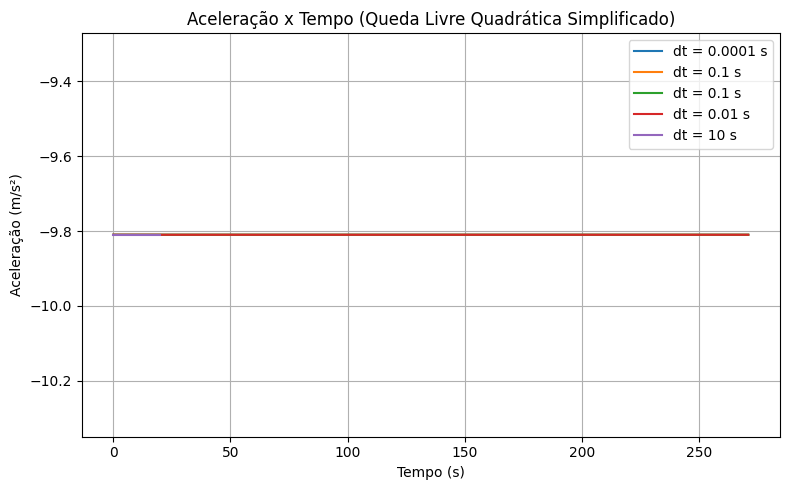

In [136]:
resultados_csv_quadratica_simplificado = {}

for dt in dt_list:
    df_quadratica_simplificado = simula_queda_livre_corpo_rigido_quadratica_simplificada(
        H, V, g, dt, c
    )
    resultados_csv_quadratica_simplificado[dt] = {
        't': df_quadratica_simplificado['tempo'].tolist(),
        'x': df_quadratica_simplificado['posicao'].tolist(),
        'v': df_quadratica_simplificado['velocidade'].tolist(),
        'a': df_quadratica_simplificado['aceleracao'].tolist()
    }
    nome_arquivo = f'saida_queda_livre_quadratica_simplificado_dt_{str(dt).replace('.', '_')}.csv'
    salvar_dados(df_quadratica_simplificado, output_corpo_rigido_quadratica_simplificado_dir, nome_arquivo)


# Plotando os gráficos
plotar_grafico_posicao_tempo(
    resultados_csv_quadratica_simplificado, dt_list, graficos_queda_livre_corpo_rigido_quadratica_simplificado_dir,
    'Queda Livre Quadrática Simplificado', 'grafico_posicao_tempo_quadratica_simplificado_multidt.png'
)
plotar_grafico_velocidade_tempo(
    resultados_csv_quadratica_simplificado, dt_list, graficos_queda_livre_corpo_rigido_quadratica_simplificado_dir,
    'Queda Livre Quadrática Simplificado', 'grafico_velocidade_tempo_quadratica_simplificado_multidt.png'
)
plotar_grafico_aceleracao_tempo(
    resultados_csv_quadratica_simplificado, dt_list, graficos_queda_livre_corpo_rigido_quadratica_simplificado_dir,
    'Queda Livre Quadrática Simplificado', 'grafico_aceleracao_tempo_quadratica_simplificado_multidt.png'
)

#### 2.3.1. Simulação com Resistência Quadrática completa

Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\quadratica_completo\saida_queda_livre_quadratica_completo_dt_0_0001.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\quadratica_completo\saida_queda_livre_quadratica_completo_dt_0_1.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\quadratica_completo\saida_queda_livre_quadratica_completo_dt_0_1.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\quadratica_completo\saida_queda_livre_quadratica_completo_dt_0_01.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\quadratica_completo\saida_queda_livre_quadratica_c

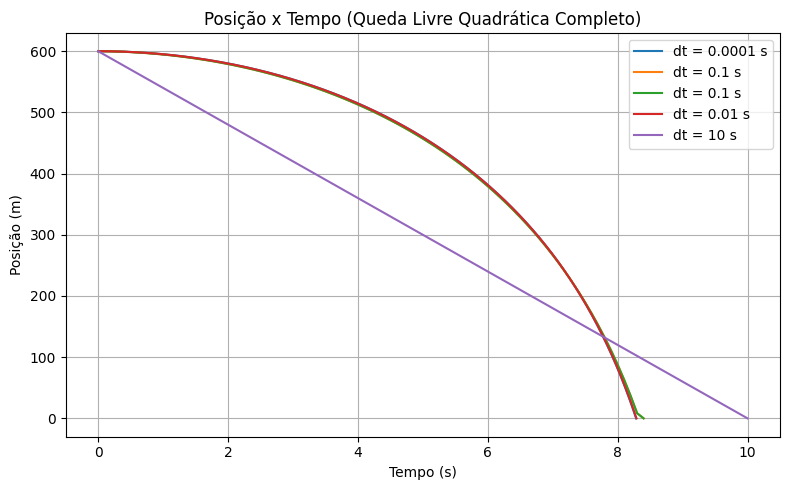

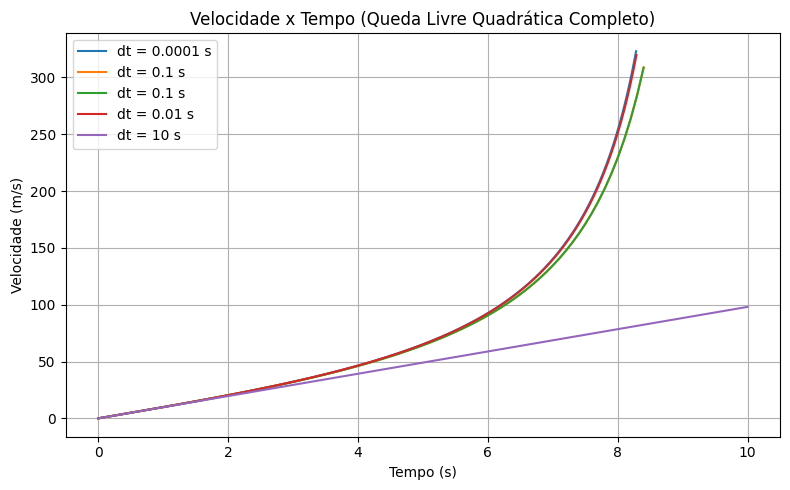

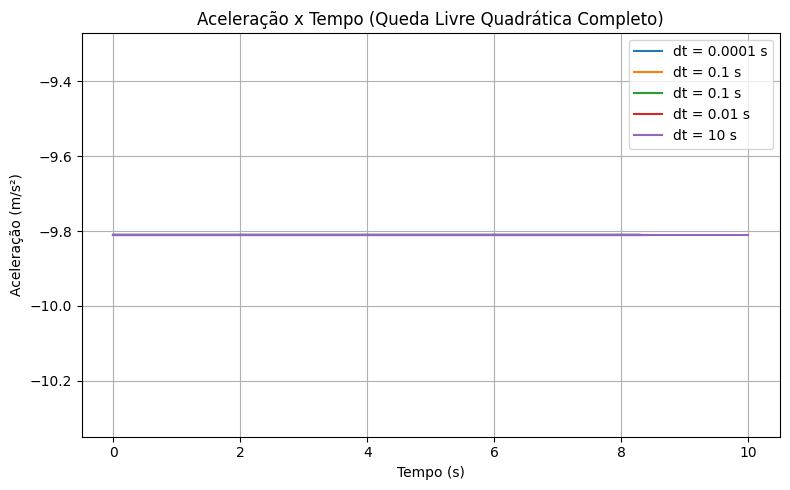

In [137]:
# Simulação, salvamento e preparação para plotagem (quadrática completa)
resultados_csv_quadratica_completo = {}

for dt in dt_list:
    df_quadratica_completo = simula_queda_livre_corpo_rigido_quadratica_completo(
        H, V, m, Cd, A, rho, g, dt
    )
    resultados_csv_quadratica_completo[dt] = {
        't': df_quadratica_completo['tempo'].tolist(),
        'x': df_quadratica_completo['posicao'].tolist(),
        'v': df_quadratica_completo['velocidade'].tolist(),
        'a': df_quadratica_completo['aceleracao'].tolist()
    }
    nome_arquivo = f'saida_queda_livre_quadratica_completo_dt_{str(dt).replace(".", "_")}.csv'
    salvar_dados(df_quadratica_completo, output_corpo_rigido_quadratica_completo_dir, nome_arquivo)

# Plotando os gráficos
plotar_grafico_posicao_tempo(
    resultados_csv_quadratica_completo, dt_list, graficos_queda_livre_corpo_rigido_quadratica_completo_dir,
    'Queda Livre Quadrática Completo', 'grafico_posicao_tempo_quadratica_completo_multidt.png'
)
plotar_grafico_velocidade_tempo(
    resultados_csv_quadratica_completo, dt_list, graficos_queda_livre_corpo_rigido_quadratica_completo_dir,
    'Queda Livre Quadrática Completo', 'grafico_velocidade_tempo_quadratica_completo_multidt.png'
)
plotar_grafico_aceleracao_tempo(
    resultados_csv_quadratica_completo, dt_list, graficos_queda_livre_corpo_rigido_quadratica_completo_dir,
    'Queda Livre Quadrática Completo', 'grafico_aceleracao_tempo_quadratica_completo_multidt.png'
)

### 2.3 Comparativo entre os Modelos

In [138]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Defina o valor de dt e o diretório de saída dos gráficos
dt = 0.00001  # Ou dt = dt_list[0] se já definido
print(dt)

graficos_dir = graficos_comparativo_dir  # Use o diretório já definido no notebook
os.makedirs(graficos_dir, exist_ok=True)

# Caminhos dos arquivos para cada modelo (sem resistência do ar, apenas quadrática completa)
base = Path('dados') / 'output'
modelos_arquivos = {
    'Sem Resistência (Partícula)': base / 'queda_livre_particula' / f'saida_queda_livre_dt_{str(dt).replace(".", "_")}.csv',
    'Linear Simplificada (Corpo Rígido)': base / 'queda_livre_corpo_rigido' / 'linear_simplificado' / f'saida_queda_livre_linear_dt_{str(dt).replace(".", "_")}_k_1_0.csv',
    'Linear Completa (Corpo Rígido)': base / 'queda_livre_corpo_rigido' / 'linear_completo' / f'saida_queda_livre_linear_completa_dt_{str(dt).replace(".", "_")}.csv',
    'Quadrática Simplificada (Corpo Rígido)': base / 'queda_livre_corpo_rigido' / 'quadratica_simplificado' / f'saida_queda_livre_quadratica_simplificado_dt_{str(dt).replace(".", "_")}.csv',
    'Quadrática Completa (Corpo Rígido)': base / 'queda_livre_corpo_rigido' / 'quadratica_completo' / f'saida_queda_livre_quadratica_completo_dt_{str(dt).replace(".", "_")}.csv'
}

# Filtra apenas os arquivos que existem
def arquivos_existentes(modelos_dict):
    return {k: v for k, v in modelos_dict.items() if v.exists()}

modelos_arquivos_existentes = arquivos_existentes(modelos_arquivos)

if not modelos_arquivos_existentes:
    print("Nenhum arquivo de saída encontrado para o dt selecionado.")
else:
    print("Modelos disponíveis para comparação:")
    for modelo, caminho in modelos_arquivos_existentes.items():
        print(f"  {modelo}: {caminho}")

    # Funções de plotagem devem estar definidas anteriormente no notebook

    # Plotar posição
    plotar_comparativo_modelos_posicao(
        dt, modelos_arquivos_existentes, graficos_dir,
        titulo='Comparativo de Modelos',
        nome_arquivo='comparativo_posicao.png'
    )

    # Plotar velocidade
    plotar_comparativo_modelos_velocidade(
        dt, modelos_arquivos_existentes, graficos_dir,
        titulo='Comparativo de Modelos',
        nome_arquivo='comparativo_velocidade.png'
    )

    # Plotar aceleração
    plotar_comparativo_modelos_aceleracao(
        dt, modelos_arquivos_existentes, graficos_dir,
        titulo='Comparativo de Modelos',
        nome_arquivo='comparativo_aceleracao.png'
    )


1e-05
Nenhum arquivo de saída encontrado para o dt selecionado.


### 2.3. Implementação do Modelo Com Resistência do Ar em Queda Livre


Agora, vamos refinar o modelo incluindo a resistência do ar proporcional à velocidade. O coeficiente de arrasto $c$ será escolhido para ilustrar o efeito.

Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_resistencia_ar\saida_queda_livre_resistencia_ar_dt_0_0001.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_resistencia_ar\saida_queda_livre_resistencia_ar_dt_0_1.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_resistencia_ar\saida_queda_livre_resistencia_ar_dt_0_1.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_resistencia_ar\saida_queda_livre_resistencia_ar_dt_0_01.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_resistencia_ar\saida_queda_livre_resistencia_ar_dt_10.csv


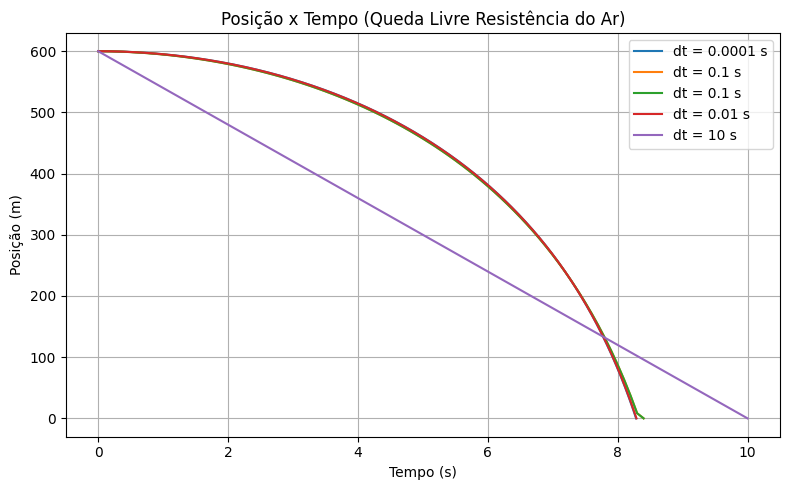

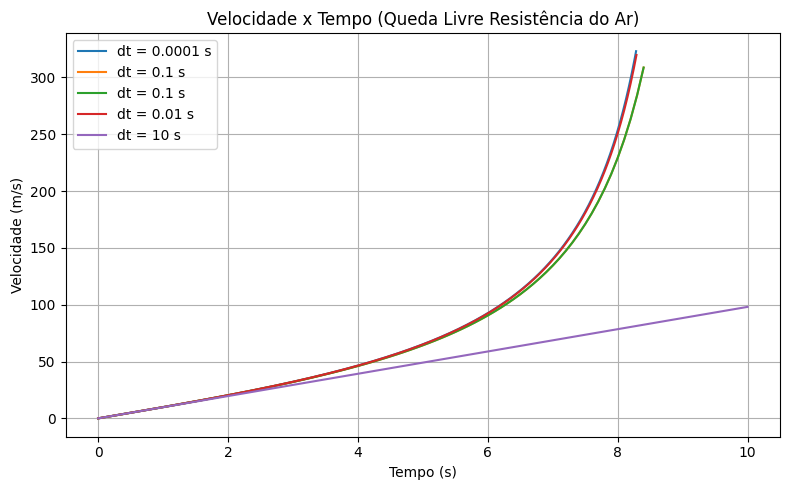

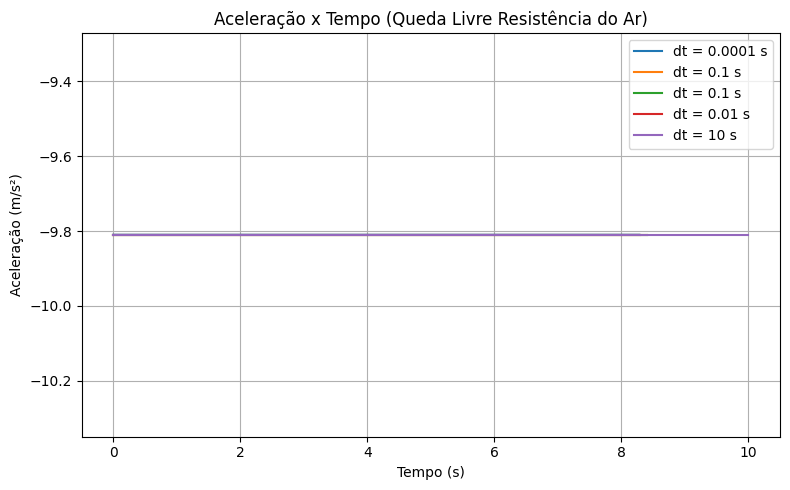

In [139]:
# Simulação, salvamento e preparação para plotagem (queda livre com resistência do ar - partícula)
resultados_csv_resistencia_ar = {}

for dt in dt_list:
    df_resistencia_ar = simula_queda_livre_corpo_rigido_quadratica_completo(
        H, V, m, Cd, A, rho, g, dt
    )
    resultados_csv_resistencia_ar[dt] = {
        't': df_resistencia_ar['tempo'].tolist(),
        'x': df_resistencia_ar['posicao'].tolist(),
        'v': df_resistencia_ar['velocidade'].tolist(),
        'a': df_resistencia_ar['aceleracao'].tolist()
    }
    nome_arquivo = f'saida_queda_livre_resistencia_ar_dt_{str(dt).replace(".", "_")}.csv'
    salvar_dados(df_resistencia_ar, output_resistencia_ar_dir, nome_arquivo)

# Garante que o diretório de gráficos existe
os.makedirs(graficos_resistencia_ar_dir, exist_ok=True)

# Plotando os gráficos
plotar_grafico_posicao_tempo(
    resultados_csv_resistencia_ar, dt_list, graficos_resistencia_ar_dir,
    'Queda Livre Resistência do Ar', 'grafico_posicao_tempo_resistencia_ar_multidt.png'
)
plotar_grafico_velocidade_tempo(
    resultados_csv_resistencia_ar, dt_list, graficos_resistencia_ar_dir,
    'Queda Livre Resistência do Ar', 'grafico_velocidade_tempo_resistencia_ar_multidt.png'
)
plotar_grafico_aceleracao_tempo(
    resultados_csv_resistencia_ar, dt_list, graficos_resistencia_ar_dir,
    'Queda Livre Resistência do Ar', 'grafico_aceleracao_tempo_resistencia_ar_multidt.png'
)

### 2.4 Estudo da Acurácia no Valor Final da Velocidade

Agora vamos analisar a acurácia do valor final da velocidade ($v_{final}$) obtido numericamente para diferentes passos de tempo ($\Delta t$), comparando com o valor analítico esperado para cada caso (com e sem resistência do ar).

Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\acuracia\acuracia_sem_resistencia.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\acuracia\acuracia_com_resistencia_linear.csv


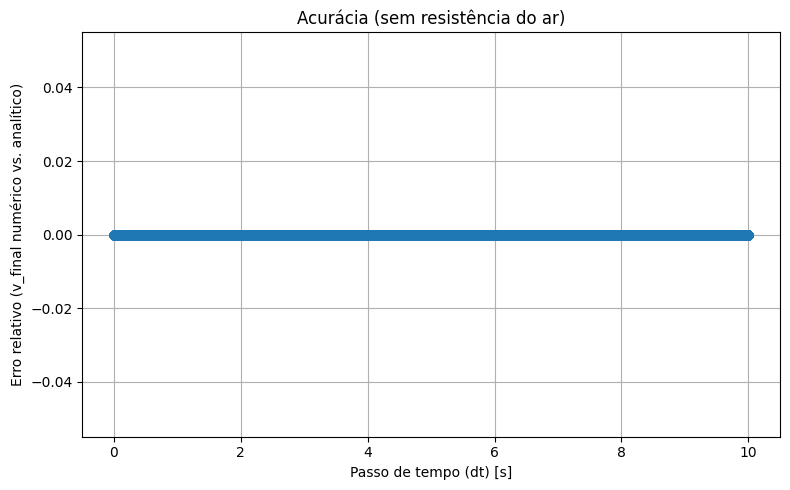

Gráfico salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\graficos\acuracia\grafico_acuracia_sem_resistencia.png


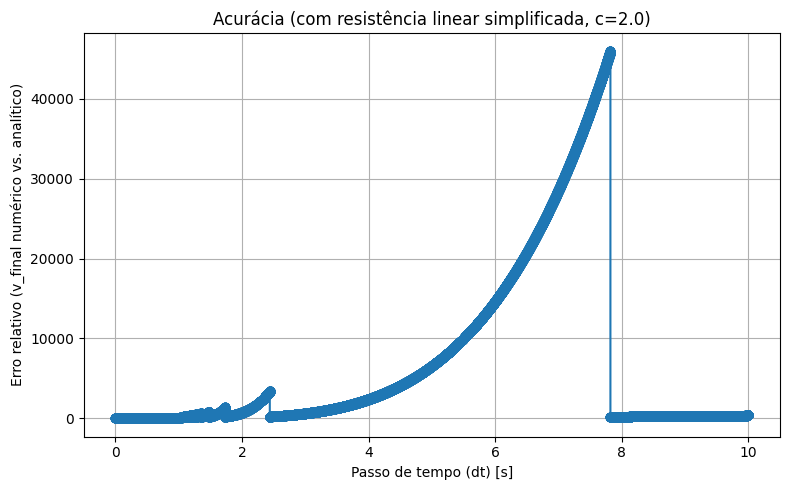

Gráfico salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\graficos\acuracia\grafico_acuracia_com_resistencia_linear_c_2_0.png


In [140]:
# ACURÁCIA CORRETA — sem resistência + linear simplificada
simula_acuracia_parametrizada(
    H=H,
    V=V,
    g=g,
    dt_inicial=dt_inicial,
    dt_final=dt_final,
    dt_step=dt_step,
    k=k,   # coeficiente da resistência linear simplificada
    output_acuracia_dir=output_acuracia_dir
)

plotar_acuracia_dt(
    caminho_csv=output_acuracia_dir / 'acuracia_sem_resistencia.csv',
    titulo='Acurácia (sem resistência do ar)',
    nome_arquivo='grafico_acuracia_sem_resistencia.png',
    graficos_dir=graficos_acuracia_dir
)

plotar_acuracia_dt(
    caminho_csv=output_acuracia_dir / 'acuracia_com_resistencia_linear.csv',
    titulo=f'Acurácia (com resistência linear simplificada, c={c})',
    nome_arquivo=f'grafico_acuracia_com_resistencia_linear_c_{str(c).replace(".", "_")}.png',
    graficos_dir=graficos_acuracia_dir
)